# Predicting Water System Violations

In [128]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd

#### Loading all the data in

In [129]:
popmean = pd.read_csv('/Users/stella/Desktop/DS Studio 2/datasets/Mean_Annual_NO3_Pop_Served_County_1994-2016_FINAL.csv')
violations = pd.read_csv('/Users/stella/Desktop/DS Studio 2/datasets/Mean_Annual_NO3_Violations_County_1994-2016_FINAL.csv')
pop = pd.read_csv('/Users/stella/Desktop/DS Studio 2/SDWIS_NO3_Pop_Served_County_1994-2016_FINAL.csv')
gw = pd.read_csv('/Users/stella/Desktop/DS Studio 2/datasets/SDWIS_Percent_GW_NO3_Violations_County_1994-2016_FINAL.csv')
sw = pd.read_csv('/Users/stella/Desktop/DS Studio 2/SDWIS_Percent_SW_NO3_Violations_County_1994-2016_FINAL.csv')

#### Create a function to clean FIPS columns and make sure it's ready for merging

In [130]:
def clean_fips(df, col):
    df['FIPS'] = df[col].astype(str).str.zfill(5)
    return df

popmean = clean_fips(popmean, 'FIPS')
violations = clean_fips(violations, 'FIPS')
pop = clean_fips(pop, 'FIPS')
gw = clean_fips(gw, 'FIPS')
sw = clean_fips(sw, 'FIPS')

#### Rename for clarity

In [131]:
gw = gw.rename(columns={'Perc_Viol' : 'pct_gw_violations'})
sw = sw.rename(columns={'Perc_Viol' : 'pct_sw_violations'})

#### Merging them together

In [132]:
df_final = gw.copy()

df_final = df_final.merge(violations[['FIPS', 'mean_viol_cnty']], on='FIPS', how='left')
df_final = df_final.merge(pop[['FIPS', 'Pop_Served']], on='FIPS', how='left')
df_final = df_final.merge(gw[['FIPS', 'pct_gw_violations']], on='FIPS', how='left')
df_final = df_final.merge(sw[['FIPS', 'pct_sw_violations']], on='FIPS', how='left')


In [133]:
df_final.head()

,State_County,State,STATE_FIPS,CNTY_FIPS,COUNTY,COUNTY2,FIPS,FIPS2,pct_gw_violations_x,mean_viol_cnty,Pop_Served,pct_gw_violations_y,pct_sw_violations
0,AK_Aleutians East Borough,AK,2,13,Aleutians East Borough,Aleutians East Borough,02013,f02013,0.000000,NaN,0,0.000000,0.0
1,AK_Aleutians West Census Area,AK,2,16,Aleutians West Census Area,Aleutians West Census Area,02016,f02016,0.621118,0.043478,697,0.621118,0.0
2,AK_Anchorage Municipality,AK,2,20,Anchorage Municipality,Anchorage Municipality,02020,f02020,0.071667,0.130435,534,0.071667,0.0
3,AK_Bethel Census Area,AK,2,50,Bethel Census Area,Bethel Census Area,02050,f02050,0.000000,NaN,0,0.000000,0.0
4,AK_Bristol Bay Borough,AK,2,60,Bristol Bay Borough,Bristol Bay Borough,02060,f02060,0.000000,NaN,0,0.000000,0.0


In [134]:
df_final.isna().sum()

State_County              0
State                     0
STATE_FIPS                0
CNTY_FIPS                 0
COUNTY                    0
COUNTY2                   0
FIPS                      0
FIPS2                     0
pct_gw_violations_x       0
mean_viol_cnty         2150
Pop_Served                0
pct_gw_violations_y       0
pct_sw_violations         0
dtype: int64

#### Dropped extra gw column (not shown) and renamed remaining

In [135]:
df_final = df_final.drop(columns=['pct_gw_violations_y'])
df_final = df_final.rename(columns={'pct_gw_violations_x' : 'pct_gw_violations'})
df_final = df_final[df_final['Pop_Served'] > 0]

In [142]:
df_final.head()

,State_County,State,STATE_FIPS,CNTY_FIPS,COUNTY,COUNTY2,FIPS,FIPS2,pct_gw_violations,mean_viol_cnty,Pop_Served,pct_sw_violations,violations_per_1000,high_violation
1,AK_Aleutians West Census Area,AK,2,16,Aleutians West Census Area,Aleutians West Census Area,02016,f02016,0.621118,0.043478,697,0.000000,0.062379,0
2,AK_Anchorage Municipality,AK,2,20,Anchorage Municipality,Anchorage Municipality,02020,f02020,0.071667,0.130435,534,0.000000,0.244260,0
7,AK_Fairbanks North Star Borough,AK,2,90,Fairbanks North Star Borough,Fairbanks North Star Borough,02090,f02090,0.303337,0.260870,1097,0.000000,0.237803,0
16,AK_Nome Census Area,AK,2,180,Nome Census Area,Nome Census Area,02180,f02180,0.000000,0.521739,2208,2.745995,0.236295,0
23,AK_Southeast Fairbanks Census Area,AK,2,240,Southeast Fairbanks Census Area,Southeast Fairbanks Census Area,02240,f02240,0.289855,0.173913,1408,0.000000,0.123518,0


#### Drop Na values for modeling

In [143]:
df_final = df_final.dropna(subset=['mean_viol_cnty'])

#### Create a column for violations per 1000, num of violatioms adjusted for population

In [137]:
df_final['violations_per_1000'] = (
    df_final['mean_viol_cnty'] / df_final['Pop_Served'] * 1000
)

### Model 1: Gradient Boosting

#### Bucketing

In [147]:
threshold = df_final['violations_per_1000'].quantile(0.75)
df_final['high_risk'] = (df_final['violations_per_1000'] > threshold).astype(int)

#### Features and target

In [148]:
X = pd.get_dummies(
    df_final[['pct_gw_violations', 'pct_sw_violations', 'State']],
    drop_first=True
)

y = df_final['high_risk']

#### Modeling

In [152]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# adjusting weight for minoirity class so the model performs better 
sample_weights = compute_sample_weight('balanced', y_train)

clf = GradientBoostingClassifier(random_state=42)
clf.fit(X_train, y_train, sample_weight=sample_weights)

y_proba = clf.predict_proba(X_test)[:, 1]  # predicting probability of being high-risk

print(f"Accuracy: {clf.score(X_test, y_test):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba):.3f}")
print(classification_report(y_test, clf.predict(X_test), target_names=['not high-risk', 'high-risk']))

Accuracy: 0.659
ROC-AUC:  0.705
               precision    recall  f1-score   support

not high-risk       0.86      0.65      0.74       200
    high-risk       0.40      0.69      0.50        67

     accuracy                           0.66       267
    macro avg       0.63      0.67      0.62       267
 weighted avg       0.74      0.66      0.68       267



### Model 2: K-Means Clustering with Silouette Score

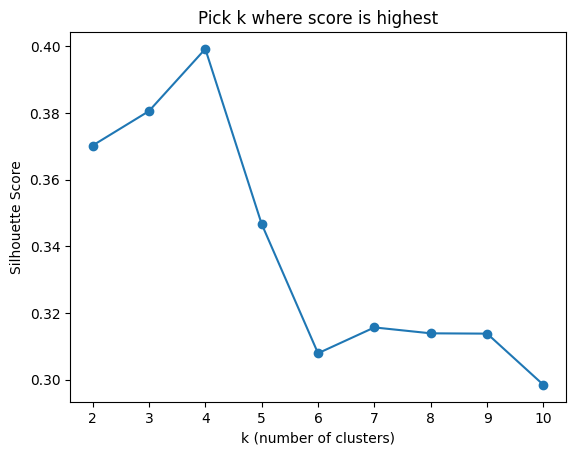

In [159]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

features = ['Pop_Served', 'pct_gw_violations', 'pct_sw_violations', 'violations_per_1000']
X = np.log1p(df_final[features])              # using log transform to fix an outlier
X_scaled = StandardScaler().fit_transform(X)  # standardizing so that K-Means treats features equally

# Try k from 2 to 10
scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    scores.append(silhouette_score(X_scaled, km.labels_))

# plotting
plt.plot(range(2, 11), scores, 'o-')
plt.xlabel('k (number of clusters)')
plt.ylabel('Silhouette Score')
plt.title('Pick k where score is highest')
plt.show()

In [161]:
# Fit K-Means with k=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_final['cluster'] = kmeans.fit_predict(X_scaled)

# results
print("Silhouette Score:", round(silhouette_score(X_scaled, df_final['cluster']), 3))
print("\nCluster sizes:")
print(df_final['cluster'].value_counts())
print("\nCluster averages:")
print(df_final.groupby('cluster')[features].mean().round(2))


Silhouette Score: 0.399

Cluster sizes:
cluster
0    520
3    309
1    211
2     25
Name: count, dtype: int64

Cluster averages:
         Pop_Served  pct_gw_violations  pct_sw_violations  violations_per_1000
cluster                                                                       
0           2868.27               0.47               0.03                 0.29
1          62162.00               6.59               0.06                 0.16
2          39621.52               5.27               5.88                 0.19
3            129.39               0.42               0.01                 1.43
